# Imports

In [7]:
import numpy as np
import os

from IPython.testing.ipunittest import count_failures
from more_itertools.recipes import reshape


%load_ext autoreload
%autoreload 2
import sys
import os


# Get the current folder path and go up one level ('..') to the project root
project_root = os.path.abspath('..')

# Add the root to the system path so Python can find 'src'
if project_root not in sys.path:
    sys.path.append(project_root)
%load_ext autoreload
%autoreload 2
from keras.src.metrics import Precision
from keras.src.metrics.metrics_utils import confusion_matrix

np.random.seed(42) #to make results reproducible

# Matplotlib and seaborn configuration
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Function to Save figures


In [8]:
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "Classification"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id , tight_layout =True, fig_extension = "png", resolution=300):
    path = os.path.join(IMAGES_PATH , fig_id + "." + fig_extension )
    print("Saving figure", fig_id )
    if tight_layout:
        plt.tight_layout()
        plt.savefig(path, format = fig_extension,dpi=resolution)

# Importing Dataset

In [9]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1 , as_frame= False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [10]:
print(mnist["frame"])
print(mnist["feature_names"])
print(mnist["target_names"])

None
['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18', 'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24', 'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30', 'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36', 'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42', 'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48', 'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54', 'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60', 'pixel61', 'pixel62', 'pixel63', 'pixel64', 'pixel65', 'pixel66', 'pixel67', 'pixel68', 'pixel69', 'pixel70', 'pixel71', 'pixel72', 'pixel73', 'pixel74', 'pixel75', 'pixel76', 'pixel77', 'pixel78', 'pixel79', 'pixel80', 'pixel81', 'pixel82', 'pixel83', 'pixel84', 'pixel85', 'pixel86', 'pixel87', 'pixel88', 'pixel89', 'pixel90', 'pixel91', 'p

In [11]:
print(mnist["categories"])

{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}


In [12]:
print("description" , mnist["DESCR"])
print("details", mnist["details"])
print("categories", mnist["categories"])
print("url", mnist["url"])

description **Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 2

In [13]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


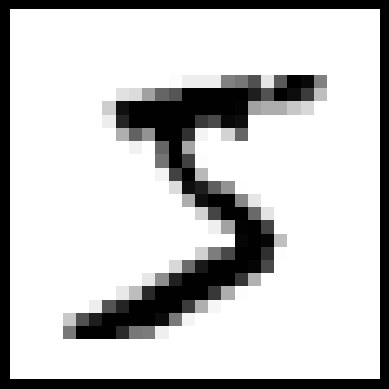

Saving figure some_digit_plot


<Figure size 640x480 with 0 Axes>

In [14]:
some_digit = X[0]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")
plt.show()
save_fig("some_digit_plot")

In [15]:
y[0]

'5'

In [16]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# 5 Detector


In [17]:
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")

In [18]:
#lets pick a classifier now and train ,1st we go with stochastic Gradient Descent Classifier
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [19]:
sgd_clf.predict(some_digit.reshape(1, -1))

array([ True])

# Performance Measures

In [20]:
# cross validation
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [21]:
# is it correct?
#dummy classifier for no 5 elements

from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [22]:
#this model accuracy
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")


array([0.90965, 0.90965, 0.90965])

it has over 90 percent accuracy for the no. is not 5 , only because 10 percent images are 5s , so most of the time is not 5 , here we can see that its not a good idea to use the accuracy as a good parameter to judge the classifier performance, especially for the skewed datasets. Here we use *Confusion Matrix (CM)*

In [23]:
# for more control on cross validation we can use StratifiedKfold

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3) #if dataset not shuffled already also add shuffle = True

for train_index , test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_folds = X_train[test_index]
    y_test_folds = y_train[test_index]

    clone_clf.fit(X_train_folds,y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct/len(y_pred))


0.0
0.0
0.0


In [24]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)


In [25]:
from sklearn.metrics import confusion_matrix, roc_auc_score

cm = confusion_matrix(y_train_5, y_train_pred)
cm
#Each row in a confusion matrix represents an actual class, while each column represents a predicted class.
#first row here shows the non-5s while the 687 here are 5s but false positive, false positives also known as type I errors,
#in 2nd row 1891 were wrongly classified as non 5s ,  False negatives are known as type II errors, while 3530 true Positives

array([[53892,   687],
       [ 1891,  3530]])

In [26]:
y_train_perfect_predictions = y_train_5 # pretend for reaching perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

since CM give u a lot of info about the data but , sometime its better to use Concise metric for positive predictions , this is known as precision of the classifier.

# Precision and Recall
it is better to combine them both to F1 score (mean of precision and recall)

In [27]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)


0.8370879772350012

In [28]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [29]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)
# increasing precision reduces
#recall, and vice versa. This is called the precision/recall trade-off.

0.7325171197343847

# Precision/Recall Trade-off
 to understand this we need to understand how SGD classifier makes its classification decisions , for each instance it uses its decision functn to compute the score. if the score is greater than the threshold it assign it to the positive class otherwise negative class.

sciket doesnt allow us to set the threshold directly but it does give u the access to decision scores , that is used for making predictions

In [30]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [31]:
threshold = 0

In [32]:
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [33]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

This confirms that raising the threshold decreases recall. The image actually
represents a 5, and the classifier detects it when the threshold is 0, but it
misses it when the threshold is increased to 3,000.
now how to decide which threshold to use ?

 First, use the
cross_val_predict() function to get the scores of all instances in the
training set, but this time specify that you want to return decision scores
instead of predictions:



In [34]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

In [35]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5,y_scores)

Saving figure precision_recall_vs_threshold_plot


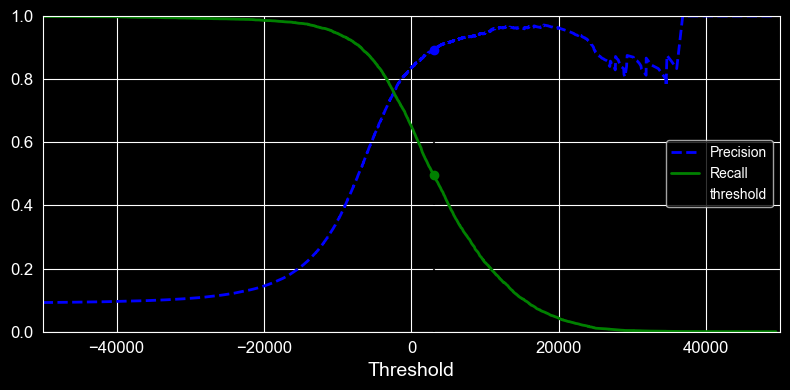

In [36]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.xlabel("Threshold")
plt.legend(loc="center right")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

Saving figure precision_vs_recall_plot


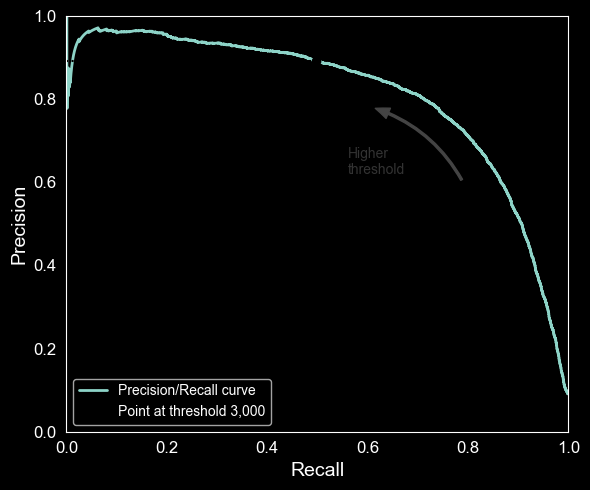

In [37]:
# another way to select a good precision/recall trade off is to plot precision directly against recall

import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()

You can see that precision really starts to fall sharply at around 80% recall.
You will probably want to select a precision/recall trade-off just before that
drop—for example, at around 60% recall. But of course, the choice depends
on your project.
Suppose you decide to aim for 90% precision. You could use the first plot to
find the threshold you need to use, but that’s not very precise. Alternatively,
you can search for the lowest threshold that gives you at least 90%
precision. For this, you can use the NumPy array’s argmax() method. This
returns the first index of the maximum value, which in this case means the
first True value:

In [38]:
idx_for_90_precision = (precisions >=0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991441826)

In [39]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [40]:
precision_score(y_train_5,y_train_pred_90)

0.9000345901072293

In [41]:
recall_at_90_precision = recall_score(y_train_5,y_train_pred_90)
recall_at_90_precision
#not great at all with 48 percent recall

0.4799852425751706

In [42]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)


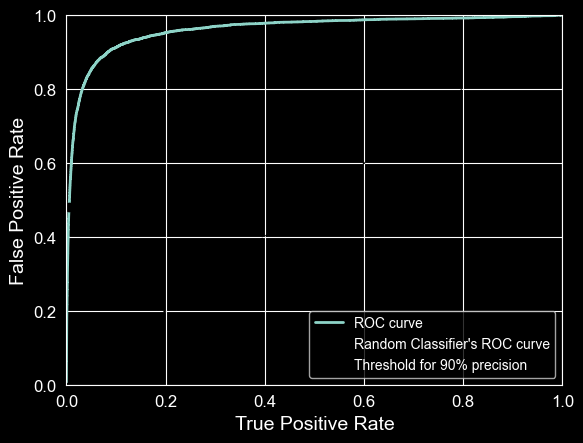

In [43]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90 , fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth = 2, label="ROC curve")
plt.plot([0,1], [0,1], "k:", label="Random Classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.xlabel("True Positive Rate")
plt.ylabel("False Positive Rate")
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right")
plt.show()

again trade off more higher recall more the false positives

In [44]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

0.9604938554008616

In [45]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
# RFC doesnt have a decision function but it has a predict_proba() method that returns class probabilities for each instance

In [46]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv = 3,  method="predict_proba")

In [47]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.98, 0.02]])

The model predicts that the first image is positive with 89% probability, and
it predicts that the second image is negative with 98% probability. Since
each image is either positive or negative, the probabilities in each row add
up to 100%.

In [48]:
y_scores_forest = y_probas_forest[:,1]

In [49]:
precisions_forest, recalls_forest , thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

Saving figure pr_curve_comparison_plot


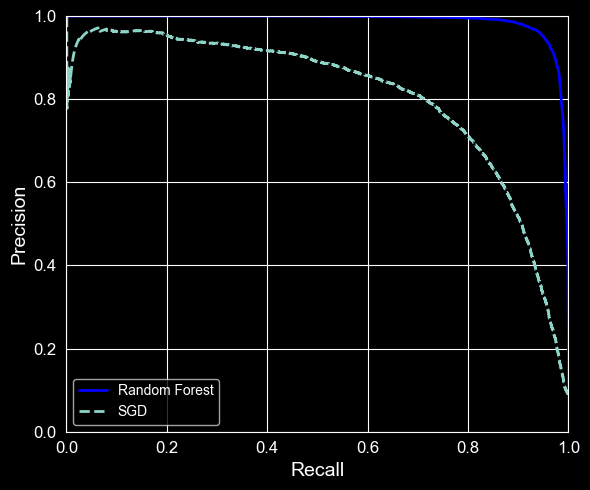

In [50]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies and saves Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower left")
save_fig("pr_curve_comparison_plot")

plt.show()

this RFC curve is way better than SGDclassifier curve , while its more closer to the top corner ,

In [51]:
y_train_pred_forest = y_probas_forest[:,1] >= 0.5 # positive proba >= 50%
f1_score(y_train_5, y_train_pred_forest)


0.9270445185330457

In [52]:
roc_auc_score(y_train_5,y_scores_forest)

0.9983296721818179

In [53]:
precision_score(y_train_5,y_train_pred_forest)

0.9895331798199707

In [54]:
recall_score(y_train_5, y_train_pred_forest)

0.8719793396052389

SVC , SGD classifier = Binary Classifiers
and Multiple class classifiers = Logistic regression, Random forest classifier , Gaussian NB


some algo like SVM scale poorly with the size of training set. for These Algorithms one vs one OVO is preffered

Scikit-Learn detects when you try to use a binary classification algorithm
for a multiclass classification task, and it automatically runs OvR or OvO,
depending on the algorithm.

In [55]:
from sklearn.svm import SVC
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000]) # only 2000 instances


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [56]:
svm_clf.predict([some_digit])
# it made 45 precic tions one per pair of classes , and it selected the class which one the most duals
#but using decision function it gives in return 10 scores per instance , each class get a score of won duels or minus a small tweak ( max +-0.33)

some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [57]:
class_id = some_digit_scores.argmax()
class_id

np.int64(5)

When a classifier is trained, it stores the list of target classes in its
classes
_ attribute, ordered by value. In the case of MNIST, the index of
each class in the classes
_ array conveniently matches the class itself (e.g.,
the class at index 5 happens to be class '5'), but in general you won’t be so
lucky

In [58]:
svm_clf.classes_


array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [59]:
svm_clf.classes_[class_id]

'5'

# Forcing OvO to OvR

In [60]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

,estimator,SVC(random_state=42)
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [61]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [62]:
len(ovr_clf.estimators_)

10

In [63]:
# training

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [64]:
# PRediction error , why ? 10 classes ,10 Binary classifier ran , lets check the cvalues using decision function
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

classifier is not very confident about its prediction:
almost all scores are very negative, while class 3 has a score of +1,824, and
class 5 is not too far behind at –1,386. Of course, you’ll want to evaluate
this classifier on more than one image. Since there are roughly the same
number of images in each class, the accuracy metric is fine.

In [65]:
cross_val_score(sgd_clf, X_train, y_train, cv = 3 , scoring= "accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [66]:
# cool , we got good accurary while on Random Classifier it will be 10 percent accuracy , simply scaling the inputs increase accuracy

In [67]:
from sklearn.preprocessing import  StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv =3, scoring="accuracy")

array([0.8983, 0.891 , 0.9018])

# ERROR ANALYSIS

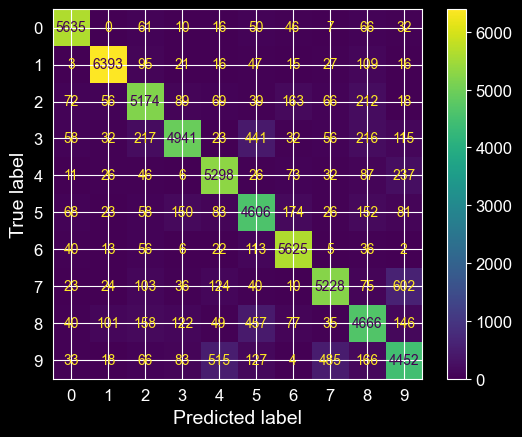

In [68]:
# 1st , Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred)
plt.show()

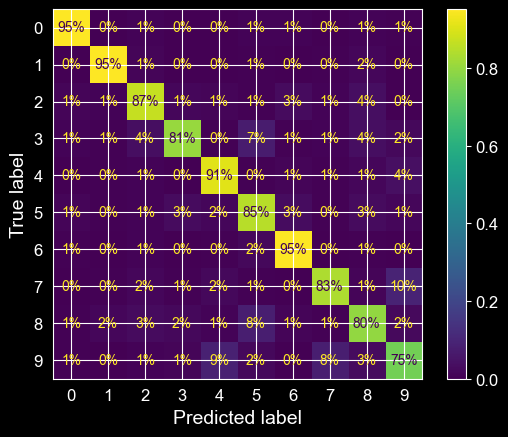

In [69]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")
plt.show()

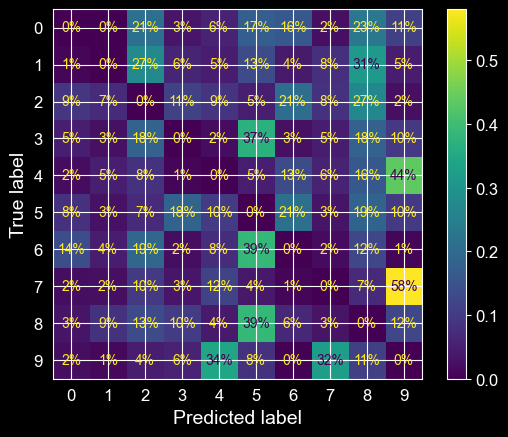

In [70]:
sample_weight = (y_train_pred != y_train) # changes the value to the negative trues
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred, sample_weight=sample_weight, normalize="true", values_format=".0%")
plt.show()
#contradictor error

In [71]:
# we see a lot of false error for 8 , so how can we improve it , we can either gather more better or new data for 8 , or u would engineer new features for the classifier
# ex writing an algorithm to count the number of closed loops (ex 8 has two , 6 has one, 5 has none ) , or process the images

# Analysing Individual errors